In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [2]:
df = pd.read_csv('../data/q2_customers.csv')
df.head()

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,30,43075,9,2080,45,6
1,19,14496,11,454,8,3
2,43,57632,6,2144,16,4
3,30,15629,10,801,0,2
4,19,14901,16,396,17,1


In [3]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

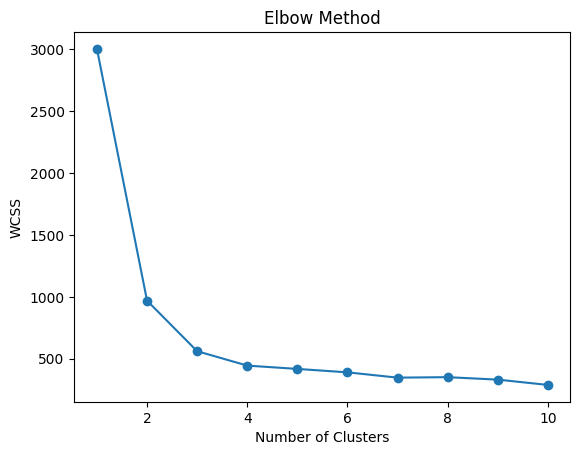

In [4]:
wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

The elbow method plot shows a sharp decrease in WCSS from K=1 to K=3, after which the rate of decrease slows significantly. This indicates that adding more clusters beyond 3 does not provide substantial improvement. Therefore, the optimal number of clusters is chosen as K = 3.


In [5]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(scaled_data)

df['cluster'] = clusters

In [6]:
centroids = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=df.columns[:-1]
)

centroids

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,24.676471,14847.370588,14.341176,558.970588,9.076471,2.111765
1,56.769697,89413.333333,2.527273,5530.545455,105.357576,7.515152
2,40.387879,43340.733333,8.193939,2021.684848,35.187879,4.424242


Cluster 0 represents younger customers who visit frequently but have moderate spending and purchase from fewer categories. These customers are highly engaged but tend to have limited variety in their purchases.

Cluster 1 consists of older customers who visit infrequently and have lower overall spending. However, they purchase from a wider range of categories, indicating diverse but irregular buying behavior. These customers appear to be less engaged.

Cluster 2 represents high-value customers with relatively high spending and moderate visit frequency. They purchase across multiple categories and show consistent engagement, making them the most valuable customer segment.


In [7]:
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

print("Explained Variance:", pca.explained_variance_ratio_)

Explained Variance: [0.83560354 0.05568764]


In [8]:
loadings = pd.DataFrame(
    pca.components_,
    columns=df.columns[:-1],
    index=['PC1', 'PC2']
)

loadings

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
PC1,0.411569,0.42154,-0.410399,0.412012,0.378582,0.414017
PC2,-0.259432,-0.03327,0.208318,-0.195402,0.911194,-0.140479


The first principal component (PC1) is strongly influenced by features such as annual spend, basket size, age, and number of categories purchased. It captures the overall value and purchasing power of customers, where higher values indicate high-spending customers and lower values indicate low-spending customers.

The second principal component (PC2) is primarily driven by days since last visit, which has a significantly high loading. This component represents customer recency, where higher values indicate customers who have not visited recently (inactive), and lower values indicate recently active customers.


The scatter plot of PC1 vs PC2 shows clear separation between the three clusters, indicating that the K-Means clustering has effectively segmented the customers. Each cluster occupies a distinct region in the reduced 2D space, suggesting meaningful differences in customer behavior across segments.


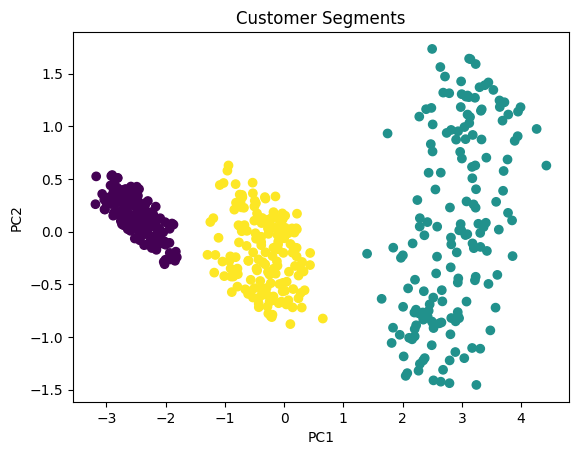

In [9]:
plt.scatter(pca_data[:, 0], pca_data[:, 1], c=clusters)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Customer Segments")
plt.show()